# Autoencoders

Autoencoders são um tipo de rede neural arquitatado para comprimir dados de entrada até seus recursos fundamentais com eficiência (codificar) e, em seguida, reconstruir os dados de entrada a partir da compactação. Uma peculiaridade interessante deste modelo é que este é um modelo de *aprendizado não supervisionado,* ou seja, não existe um target que queremos prever ou classificar uma vez que o target são os próprios dados de entrada. Na prática, já que ainda existe um conjunto de dados a se comparar com a saída do modelo para medir o desempenho do modelo, podemos classificar os autoencoders também como modelos de *aprendizado autossupervisionado* (daí vem o auto de autoencoder).

Esse tipo de rede neural tem várias aplicações diferentes, como redução de ruído, reconhecimento de anomalias, reconhecimento facial e até tarefas generativas, como os autoencoders variacionais.

## Variáveis latentes

Em uma distribuição de dados, existem variáveis ocultas ou aleatórias que guardam informações sobre como os dados são distribuídos. Essas variáveis são chamadas de variáveis latentes. O conjunto de variáveis latentes dos dados de entrada é chamado de *espaço latente*. Treinar o autoencoder é identificar quais variáveis latentes podem ser usadas para reconstruir os dados entrada.

## Estrutura dos Autoencoders:
Um autoencoder é uma rede neural estruturada em 3 partes: um codificador, um código (ou gargalo) e um decodificador. Diferentes tipos de autoencoders podem possuir elementos diferentes em sua estrutura, mas a base é essa.


<img src=Autoencoders-3.webp alt="desc" width=600></img>


### Codificador:
As camadas codificadoras atuam reduzindo a dimensionalidade dos dados de entrada. As camadas progressivamente diminuem suas quantidades de neurônios na medida em que os dados a atravessam, reduzindo a dimensionalidade das informações às partes mais importantes.

### Código ou gargalo:
É a camada de saída do codificador e a camada de entrada do decodificador. Contém as representações mais comprimidas dos dados de entrada. O objetivo do treinamento de um autoencoder é descobrir a menor quantidade possível de informações capazes de reconstruir os dados de entrada. A saída dessa camada é o espaço latente, que alimentará as camadas decodificadoras.

### Decodificador:
O decodificador faz o trabalho inverso do codificador. Possui uma estrutura que aumenta a quantidade de neurônios por camada progressivamente a fim de descomprimir o espaço latente e reconstruir os dados originais. A saída do decodificador é comparada com os dados de entrada a fim de verificar a semelhança com os dados originais. A diferença entre a entrada e a saída é chamada de **erro de reconstrução**.

## Parâmetros importantes para otimizar o Autoencoder
Diferentes estruturas de autoencoders geram diferentes comportamentos da rede neural frente aos dados. Os principais hiperparâmetros a serem otimizados são:

- Tamanho do gargalo: Define o nível de compressão dos dados. Pode ser usado para evitar overfit e underfit.
- Profundidade: Define a complexidade da rede pelo número de camadas no codificador e no decodificador. Redes mais profundas são mais complexas e pode ser mais poderosa, mas será mais pesada. 
- Largura das camadas: Diminui durante o codificador, chega a um mínimo no gargalo e aumenta com o decodificador. Podem existir variantes. Pode variar de acordo com a natureza dos dados.
- Função de perda: Depende da tarefa a ser realizada pelo autoencoder.


## Regularização de Autoencoders
Vamos supor que seu professor te dê a seguinte tarefa: copie este desenho da forma mais exata o possível. Você tem dois métodos para fazer isso: identificar as partes do desenho e redesenhar as formas manualmente, ou ir lá em baixo e tirar um xerox do desenho. É lógico de se imaginar que seu professor não ficaria muito feliz com uma fotocópia do desenho que ele te mandou redesenhar, mas ele não disse como você deveria fazer sua tarefa. O que ele poderia fazer para evitar isso?

Um problema que pode acontecer durante o treinamento e uso de Autoencoders é o modelo criado não identificar os elementos principais dos dados de entrada, mas apenas memorizar e copiar a entrada, tornando-se inútil. Para contornar isso, usam-se estratégias de regularização. A regularização é o processo de impor restrições ao funcionamento do modelo, conferindo-lhe novas funcionalidades.

### Autoencoders esparsos
Os autoencoders esparsos impõem uma restrição ao funcionamento do modelo ao não ativar todos os neurônios simultaneamente, penalizando o modelo para cada neurônio ativado acima do limite. Isso permite que o modelo fique menos sujeito a sobreajustes e que neurônios específicos sejam dedicados a uma determinada função, ativando esses neurônios apenas quando necessário. Isso é feito impondo penalidades à função de perda, como por exemplo, a L1, ou regularização LASSO.

Neste caso, vamos utilizar a penalidade L1, ou regularização Lasso. Essa penalidade é definida como a soma de todos os os parâmetros de um modelo (essa penalidade é normalmente utilizada em contextos de regressão linear). A loss function da rede neural com a penalidade é dada por:


$\mathcal{L} = MSELoss + \lambda \sum |w|$

Em que w é um parâmetro da rede neural.

Ao tentar minimizar a penalidade, forçamos o otimizador a reduzir -ou zerar- pesos do autoencoder, enfraquecendo ou desativando neurônios, por isso chamamos este modelo de autoencoder esparso, porque poucos neurônios são utilizados.  

### Denoising
A estratégia de denoising se baseia em forçar o autoencoder a aprender a retirar o ruído de um sinal de entrada. Para forçar o modelo a entender o espaço latente e não copiar simplesmente a entrada, aplica-se um ruído à entrada bruta e treina-se o modelo para retirar o ruído da entrada.

### Autoencoders contráteis
São uma alternativa à estratégia de denoising. Neste caso, aplica-se uma regularização no treinamento que penaliza o modelo caso este se apegue demais a pequenas variações (ruído). Essa penalidade é dada pela *norma de Frobenius da matriz jacobiana usada na função de perda do backpropagation* (???). Quando calculamos o backpropagation do modelo, obtemos as derivadas da função de perda durante o treino do modelo. Colocamos todas essas derivadas dentro de uma matriz. A matriz de todas as derivadas de primeira ordem de uma função é chamada de *matriz jacobiana*. A p-norma de um objeto (vetor, matriz) é dada pela soma dos módulos de todos os elementos elevados a p do objeto elevada a 1/p. Por exemplo, dada uma matriz $A$ $m\times n$, a 2-norma (norma de Frobenius) dessa matriz será calculada da seguinte forma:

$||A||_2=(\sum_{i=1}^{m} \sum_{j=1}^{n} |a_{ij}|^{2})^{1/2}$

Ao minimizar a norma de frobenius da matriz jacobiana do nosso modelo, na prática, estamos enfraquecendo a influência do ruído na reconstrução das imagens, uma vez que reduzimos os pesos associados a derivadas grandes. A tarefa de calcular o jacobiano de uma matriz pode não ser fácil, principalmente para modelos grandes. Por isso, aproximamos seu valor utilizando um estimador de Hutchinson, um método estocástico para determinar o traço (soma dos valores da diagonal principal) de uma matriz utilizando o produto de um vetor com entradas estocásticas (vetor de Rademacher ou gaussiano) pelo jacobiano desta matriz. 


## Partindo para a prática
Vamos agora testar o funcionamento de autoencoders para tentar reconstruir uma imagem. Para isso, pegaremos uma imagem em preto e branco (trabalhar com cores aqui exigiria algo *muito* além do escopo deste trabalho), transformaremos em uma matriz, aplicaremos normalização pelo máximo e treinaremos uma rede neural do tipo autoencoder para reconstruir a imagem. 

A imagem que utilizaremos é essa:

<img src=imagem.png width=80></img>

Fonte da imagem: https://www.hiclipart.com/free-transparent-background-png-clipart-mglea

Vamos tentar reconstruir esta imagem utilizando autoencoders (infelizmente tivemos que reduzir a qualidade da imagem caso contrário teríamos um modelo MUITO pesado). Faremos da seguinte forma: primeiro, vamos utilizar um autoencoder incompleto, sem regularização para ver o que acontece. Depois, vamos testar as diferentes formas de regularização e ver o que acontece quando as aplicamos no nosso modelo. Uma vez que as redes neurais ficaram muito grandes, foi necessário rodar os modelos em HPC. Devido a estabilidade do sistema, utilizamos scripts em python para treinar os modelos. 

### Estrutura padrão das redes neurais:
Apesar da prática não ser recomendada, neste trabalho, não otimizaremos os hiperparâmetros do modelo devido ao tamanho da rede neural resultante, o que demoraria muito tempo para rodar mesmo utilizando computação de alto desempenho.

As redes neurais terão 6 camadas no total: duas extremidades (entrada e saída) com número de neurônios igual ao número de pixels da imagem, duas camadas intermediárias com metade dos neurônios das camadas de entrada e saída e duas camadas de gargalo com metade dos neurônios das camadas intermediárias.

As redes neurais serão criadas utilizando o pacote Lightning. Utilizaremos como função de ativação a função Sigmoide (uma função derivável em todos os seus pontos) e como função de perda, o MSE. O autoencoder é a junção de duas redes neurais: um encoder e um decoder, do tipo `nn.Sequential`. Os dois são conectados por meio de entradas e saídas no forward-pass, em que a saída do encoder é a entrada do decoder.

### Estrutura do projeto:
O arquivo *rede_neural.py* contém as classes necessárias para treinar e executar o modelo. As classes são *DataModule* (responsável pela importação e processamento de dados) e *Autoencoder* (o modelo em si). A classe *Autoencoder* possui funções auxiliares para o cálculo das regularizações, no caso, **frobenius**, que aproxima a norma de frobenius do jacobiano do modelo para autoencoders contráteis. As funções de perda são calculadas pelas funções lambda **f_perda_pura**, **f_perda_l1** e **f_perda_c**, que recebem os mesmos parâmetros (self, x (os dados de entrada), y_pred (o retorno do modelo) e y (o valor real)) para permitir que sejam chamadas da mesma forma nos passos de treino, teste e validação. A função `encode` permite encontrar acessar os valores comprimidos pelo autoencoder, podendo ser utilizados em outros modelos. Utilizaremos learning-rate de 0.001, e diferentes valores de pesos de regularização.

O arquivo *leitor_imagem.py* contém funções úteis para a manipulação de imagens a serem utilizadas no treinamento. Há três funções no arquivo: **read_image(nome do arquivo)** que lê o arquivo de imagem e retorna uma matriz, o formato da matriz e o número de pixels da imagem, **ruido(matriz)** que lê uma matriz de imagem e retorna a mesma com um ruído gaussiano aplicado, e **rebuild(matriz, formato)** que pega uma matriz, ou vetor, e reconstrói na imagem original.

O arquivo *treinar.py* é responsável pelo treinamento de cada modelo. Pode ser executado em terminal passando as configurações do modelo. A sintaxe de utilização é: `python treinar.py imagem *params`. Os parâmetros de utilização são:

- `-p [int]`: é a paciência do algoritmo de early stopping. Se for 0, o treinador executará todas as épocas passadas. Valor padrão: 5.
- `-e [int]`: é o número de épocas que o treinador vai executar. Valor padrão: 500.
- `-lr [float]`: é a taxa de aprendizado do modelo. Valor padrão: 0.001.
- `-d`: executa o autoencoder no modo *denoise*.
- `-l1 (peso da penalidade)[float]`: executa o autoencoder no modo *esparso*.
- `-c (peso da penalidade)[float]`: executa o autoencoder no modo *contráctil*.
- `-n (número de camadas)[int, par]`: Número de camadas do autoencoder
- `-f (decaimento)[float dentro de ]0, 1[]`: Fração entre o número de neurônios da camada atual e da camada anterior. 
- As penalidades têm como valor padrão 1e-4.
- Exemplo de uso para um autoencoder contrátil com fator de penalidade 0.004, 1000 épocas, paciência de 10 épocas, 4 camadas e decaimento de 0.3: `python treinar.py imagem.png -c 4*1e-3 -e 1000 -p 10 -n 4 -f 0.3`

Como dito anteriormente, as redes neurais instanciadas por este script seguem uma estrutura simétrica na entrada e saída. 

Este script tem duas saídas: um arquivo de pesos e viéses do pytorch `.pth` e uma imagem com os gráficos das curvas de aprendizado de treino e validação do modelo. Caso seja usado o modo Denoise, haverá também uma imagem de saída com ruído.


### Demonstração: 
A célula abaixo permite a montagem rápida de um autoencoder utilizando os parâmetros acima. Para isso, chamamos o arquivo *treinar.py* por meio do comando mágico `%run`.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | fun_perda | MSELoss    | 0      | train | 0    
1 | encoder   | Sequential | 1.0 M  | train | 0    
2 | decoder   | Sequential | 1.0 M  | train | 0    
---------------------------------------------------------
2.0 M     Trainable params
0         Non-trainable params
2.0 M     Total params
8.040     Total estimated model params size (MB)
7         Modules in train mode
0  

-------------------- INICIANDO TREINADOR DE REDES NEURAIS --------------------
TIPO DE REDE NEURAL: Contrátil
SEM PARADA ANTECIPADA
NÚMERO DE CAMADAS: 2 
NEURÔNIOS POR CAMADA: [10000, 100] 
NEURÔNIOS TOTAIS: 10100 

[10000, 100]
[100, 10000]
-------------------- INICIANDO TREINAMENTO
                                                                            

c:\Users\vitor25023\OneDrive - ILUM ESCOLA DE CIÊNCIA\Documentos\Redes Neurais\Trilha_Academica\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\vitor25023\OneDrive - ILUM ESCOLA DE CIÊNCIA\Documentos\Redes Neurais\Trilha_Academica\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
c:\Users\vitor25023\OneDrive - ILUM ESCOLA DE CIÊNCIA\Documentos\Redes Neurais\Trilha_Academica\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in

Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 11.50it/s, v_num=75, loss=0.0012, val_loss=0.00119] 

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  5.49it/s, v_num=75, loss=0.0012, val_loss=0.00119]


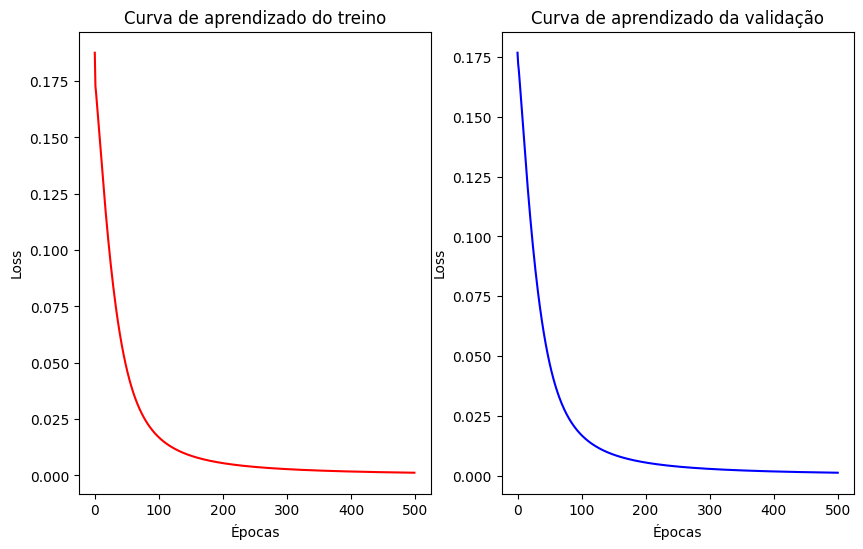

In [20]:
%run treinar.py imagem.png -c 0.003 -p 0 -e 500 -lr 0.001 -n 4 -f 0.01 -cpu 1

modelo = autoencoder
dm = dm

In [21]:
# Importações
import rede_neural
import leitor_imagem
import torch
import torch.nn as nn
import lightning as L
import numpy as np
from sklearn.metrics import root_mean_squared_error

In [22]:
img, sz, n_i = leitor_imagem.read_image("imagem.png")
modelo.eval()
dm.setup("test")
with torch.no_grad():
    X_true = dm.input_test
    y_true = dm.target_test

    y_pred = modelo(X_true)
    RMSE = root_mean_squared_error(y_true, y_pred)

    leitor_imagem.rebuild(y_pred, sz, outname="kurisu_reconstruida_exemplo.png")
    espaço_latente = modelo.encode(X_true)

In [23]:
print(f"RMSE do modelo: {RMSE}")

RMSE do modelo: 0.026224695146083832


#### Resultados da demonstração:
Abaixo estão a imagem original e a  reconstruída.

Imagem original:------------Imagem Reconstruída:

<img src=imagem.png width=200></img> <img src=kurisu_reconstruida_exemplo.png width=200></img>

Nota-se uma diferença na cor das imagens, mas os detalhes da imagem são reconstruídos fielmente, o que mostra que o desempenho do modelo é muito bom. Como neste exemplo não usamos nenhuma regularização, muito provavelmente o modelo está sobreajustado e apenas decorando a imagem. Experimente treinar a rede com outros parâmentros e veja o que acontece! :)


### Resultados dos testes com grandes redes e grandes regularizações:
Foram testados diferentes tipos de regularizações com a mesma imagem em uma rede de 6 camadas. Vamos ver os resultados aqui:

#### Autoencoder incompleto:


In [ ]:
%run treinar.py imagem.png -nf -e 100 -p 10 -n 6 -f 0.5 
uncomplete = autoencoder 
dmu = dm

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\vitor25023\OneDrive - ILUM ESCOLA DE CIÊNCIA\Documentos\Redes Neurais\Trilha_Academica\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Número de épocas inválido. Usando valor padrão de 0.5
-------------------- INICIANDO TREINADOR DE REDES NEURAIS --------------------
TIPO DE REDE NEURAL: Incompleto
PARADA ANTECIPADA COM 10 ÉPOCAS
NÚMERO DE CAMADAS: 3 
NEURÔNIOS POR CAMADA: [10000, 5000, 2500] 
NEURÔNIOS TOTAIS: 17500 

[10000, 5000, 2500]
[2500, 5000, 10000]


In [ ]:
img, sz, n_i = leitor_imagem.read_image("imagem.png")


uncomplete.eval()
dm.setup("test")


state_dict = torch.load("imagem.png_.pth", weights_only=True)
uncomplete.load_state_dict(state_dict)

with torch.no_grad():
    X_true = dmu.input_test
    y_true = dmu.target_test

    y_pred = uncomplete(X_true)
    RMSE = root_mean_squared_error(y_true, y_pred)

    leitor_imagem.rebuild(y_pred, sz, outname="kurisu_reconstruida.png")
    espaço_latente = uncomplete.encode(X_true)

In [ ]:
print(f"O RMSE do modelo foi {RMSE}")


O RMSE do modelo foi 0.002036870690062642


##### Curva de aprendizado do modelo:

<img src=imagem.png_.png></img>

##### Comparação das imagens de entrada e saída:

Imagem original:------------Imagem Reconstruída:

<img src=imagem.png width=200></img> <img src=kurisu_reconstruida.png width=200></img>


#### Autoencoder esparso

In [ ]:

%run treinar.py imagem.png -nf -l1 0.005 -p 0 -e 100 -n 6 -f 0.5 -cpu 1
sparse = autoencoder 
dms = dm

img, sz, n_i = leitor_imagem.read_image("imagem.png")


state_dict = torch.load("imagem.png_l1.pth", weights_only=True)
sparse.load_state_dict(state_dict)

sparse.eval()
dms.setup("test")
with torch.no_grad():
    X_true = dms.input_test
    y_true = dms.target_test

    y_pred = sparse(X_true)
    RMSE = root_mean_squared_error(y_true, y_pred)

    leitor_imagem.rebuild(y_pred, sz, outname="kurisu_reconstruida_sparse.png")
    espaço_latente = sparse.encode(X_true)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Número de épocas inválido. Usando valor padrão de 0.5
-------------------- INICIANDO TREINADOR DE REDES NEURAIS --------------------
TIPO DE REDE NEURAL: Esparso
SEM PARADA ANTECIPADA
NÚMERO DE CAMADAS: 3 
NEURÔNIOS POR CAMADA: [10000, 5000, 2500] 
NEURÔNIOS TOTAIS: 17500 

[10000, 5000, 2500]
[2500, 5000, 10000]


In [ ]:
print(f"RMSE do modelo: {RMSE}")

RMSE do modelo: 0.39120298624038696


##### Curva de aprendizado do modelo:

<img src=imagem.png_l1.png></img>

##### Comparação das imagens de entrada e saída:

Imagem original:--------------Imagem reconstruída

<img src=imagem.png width=200></img> <img src=kurisu_reconstruida_sparse.png width=200></img>

#### Autoencoder denoise:

In [ ]:
%run treinar.py imagem.png -nf -d -e 100 -p 10 -n 6 -f 0.5

denoiser = autoencoder 
dmd = dm


state_dict = torch.load("imagem.png_d.pth", weights_only=True)
denoiser.load_state_dict(state_dict)

img, sz, n_i = leitor_imagem.read_image("imagem.png")

denoiser.eval()
dmd.setup("test")
with torch.no_grad():
    X_true = dmd.input_test
    y_true = dmd.target_test

    y_pred = denoiser(X_true)
    RMSE = root_mean_squared_error(y_true, y_pred)

    leitor_imagem.rebuild(y_pred, sz, outname="kurisu_reconstruida_denoise.png")
    espaço_latente = denoiser.encode(X_true)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Número de épocas inválido. Usando valor padrão de 0.5
-------------------- INICIANDO TREINADOR DE REDES NEURAIS --------------------
TIPO DE REDE NEURAL: Denoise
IMAGEM COM RUÍDO GERADA COM NOME: noised_imagem.png.png
PARADA ANTECIPADA COM 10 ÉPOCAS
NÚMERO DE CAMADAS: 3 
NEURÔNIOS POR CAMADA: [10000, 5000, 2500] 
NEURÔNIOS TOTAIS: 17500 

[10000, 5000, 2500]
[2500, 5000, 10000]


In [ ]:
print(f"O RMSE do modelo foi de: {RMSE}")

O RMSE do modelo foi de: 0.07985350489616394


##### Curva de aprendizado do modelo:

<img src=imagem.png_d.png></img>

##### Comparação das imagens de entrada e saída:

Imagem original:------------Imagem com ruído:---------Imagem reconstruída

<img src=imagem.png width=200></img> <img src=noised_imagem.png.png width=200></img> <img src=kurisu_reconstruida_denoise.png width=200></img>

#### Autoencoder contrátil


In [ ]:
%run treinar.py imagem.png -nf -c 1e-3 -e 100 -p 5 -n 6 -f 0.5

contrac = autoencoder 
dmc = dm


state_dict = torch.load("imagem.png_c.pth", weights_only=True)
contrac.load_state_dict(state_dict)

img, sz, n_i = leitor_imagem.read_image("imagem.png")

contrac.eval()
dmc.setup("test")
with torch.no_grad():
    X_true = dmc.input_test
    y_true = dmc.target_test

    y_pred = contrac(X_true)
    RMSE = root_mean_squared_error(y_true, y_pred)

    leitor_imagem.rebuild(y_pred, sz, outname="kurisu_reconstruida_contractive.png")
    espaço_latente = contrac.encode(X_true)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Número de épocas inválido. Usando valor padrão de 0.5
-------------------- INICIANDO TREINADOR DE REDES NEURAIS --------------------
TIPO DE REDE NEURAL: Contrátil
PARADA ANTECIPADA COM 5 ÉPOCAS
NÚMERO DE CAMADAS: 3 
NEURÔNIOS POR CAMADA: [10000, 5000, 2500] 
NEURÔNIOS TOTAIS: 17500 

[10000, 5000, 2500]
[2500, 5000, 10000]


In [ ]:
print(f"O RMSE do modelo foi de: {RMSE}")

O RMSE do modelo foi de: 0.0020506393630057573


##### Curva de aprendizado do modelo:

<img src=imagem.png_c.png></img>
##### Comparação da entrada e saída:
Imagem original:------------Imagem Reconstruída:

<img src=imagem.png width=200></img> <img src=kurisu_reconstruida_contractive.png width=200></img>

#### Discussão dos resultados: 
Em geral, é possível identificar um bom desempenho dos modelos. Os modelos que melhor tiveram resultado em reconstruir as imagens originais foram os autoencoders puro (incompleto) e contrátil. O autoencoder denoise, apesar de convergir rápido durante o treinamento, não conseguiu reconstruir os dados de entrada durante o teste. O autoencoder esparso convergiu com dificuldade, mostrando muita oscilação com o passar das épocas de treino. Seu desempenho não foi satisfatório, não conseguindo reconstruir a imagem.

Muito provavelmente, os modelos que obtiveram pior desempenho não foram treinados com seus hiperparâmetros ótimos, uma vez que não otimizamos os hiperparâmetros já que este não é o objetivo deste projeto. 

## "E para que eu vou usar isso na minha vida?"
A principal função de um autoencoder é redução de dimensionalidade. Poderíamos utilizar algoritmos como a análise de componentes principais (PCA), entretanto, este método possui algumas limitações, dentre elas, assumir a linearidade entre os dados. 

Redes neurais têm a principal característica de permitir a observação de padrões não lineares entre os dados, sendo capazes de aproximar qualquer função. Ao usar este tipo de algoritmo para reduzir a dimensionalidade de dados de entrada, podemos escolher o nível de compressão dos dados de forma não linear, tornando a rotina mais precisa. Um autoencoder deve manter a maior quantidade de informações necessárias dentro de um número reduzido de dimensões, portanto, a arquitetura da rede neural deve levar em conta a aplicação final do modelo.

Autoencoders podem estar associados a outros tipos de algoritmos de aprendizado de máquina, podendo ser usados, por exemplo, para reconhecimento de expressões faciais [1]. Um autoencoder deve manter a maior quantidade de informações necessárias dentro de um número reduzido de dimensões, portanto, a arquitetura da rede neural 

## Referências:

[1] USMAN, Muhammad; LATIF, Siddique; QADIR, Junaid. Using Deep Autoencoders for Facial Expression Recognition. arXiv, 2018. Disponível em: https://arxiv.org/pdf/1801.08329. Acesso em: 12 maio 2026.

https://www.deeplearningbook.com.br/introducao-aos-autoencoders/

https://www.deeplearningbook.com.br/principais-tipos-de-redes-neurais-artificiais-autoencoders/

https://www.deeplearningbook.com.br/variational-autoencoders-vaes-definicao-reducao-de-dimensionalidade-espaco-latente-e-regularizacao/

https://www.ibm.com/br-pt/think/topics/autoencoder

Este projeto foi feito com auxílio de IA generativa. A conversa que auxiliou este trabalho está disponível em: https://claude.ai/chat/51dc01b1-08c1-45a9-84b9-e6817429a916
